In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose `sp500_daily (1).csv` in the dialog

# Get the actual uploaded filename (key of the dict)
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename)

# Basic checks
print(df.columns)
df.head()

Saving sp500_daily (1).csv to sp500_daily (1).csv
Loaded file: sp500_daily (1).csv


/tmp/ipykernel_51898/342386427.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


Index(['Unnamed: 0', 'date', 'permno', 'comnam', 'ncusip', 'shrcd', 'exchcd',
       'hsiccd', 'ticker', 'gvkey', 'iid', 'start', 'ending', 'ret', 'retx',
       'prc', 'shrout', 'vol', 'cfacpr', 'cfacshr'],
      dtype='object')


,Unnamed: 0,date,permno,comnam,ncusip,shrcd,exchcd,hsiccd,ticker,gvkey,iid,start,ending,ret,retx,prc,shrout,vol,cfacpr,cfacshr
0,1,2000-01-03,11703,DU PONT E I DE NEMOURS & CO,26353410,11,1,2879,DD,4087,1,1957-03-01,2017-08-31,-0.013283,-0.013283,65.0000,1043131.0,2791500.0,1.053752,1.0
1,2,2000-01-03,24766,NORTHROP GRUMMAN CORP,66680710,11,1,3812,NOC,7985,1,1985-06-13,2024-12-31,-0.021965,-0.021965,52.8750,69489.0,152100.0,2.220592,2.0
2,4,2000-01-03,24563,TEXAS UTILITIES CO,88284810,11,1,4911,TXU,10507,1,1957-03-01,2007-10-09,-0.028120,-0.028120,34.5625,276407.0,1029700.0,2.000000,2.0
3,5,2000-01-03,40416,AVON PRODUCTS INC,05430310,11,1,2844,AVP,1920,1,1967-05-18,2015-03-20,-0.037879,-0.037879,31.7500,242304.0,944400.0,2.000000,2.0
4,6,2000-01-03,26710,LOEWS CORP,54042410,11,1,6331,LTR,6781,1,1995-05-10,2024-12-31,-0.026777,-0.026777,59.0625,106050.0,413700.0,6.000000,6.0


Unique dates in filtered data: 6289
Unique permnos in filtered data: 978
Raw panel shape (T x N): (6289, 978)
Universe size summary:
count    6289.000000
mean      346.660836
std        34.025598
min         0.000000
25%       350.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64

First few nonempty universes:
2000-03-29 -> 350 stocks
2000-03-30 -> 350 stocks
2000-03-31 -> 350 stocks
2000-04-03 -> 350 stocks
2000-04-04 -> 350 stocks
#dates in full panel: 6289
Universe size summary:
count    6289.000000
mean      346.660836
std        34.025598
min         0.000000
25%       350.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64
6228 6228
Optimized portfolio:
  mean_ret_monthly: 0.0006
  vol_annual: 0.0495
  sharpe_annual: 0.1513
  max_drawdown: -0.5302
  cum_return: 24.7243

Equal-weight benchmark:
  mean_ret_monthly: 0.0005
  vol_annual: 0.0440
  sharpe_annual: 0.1337
  max_drawdown: -0.5703
  cum_return: 11.7823


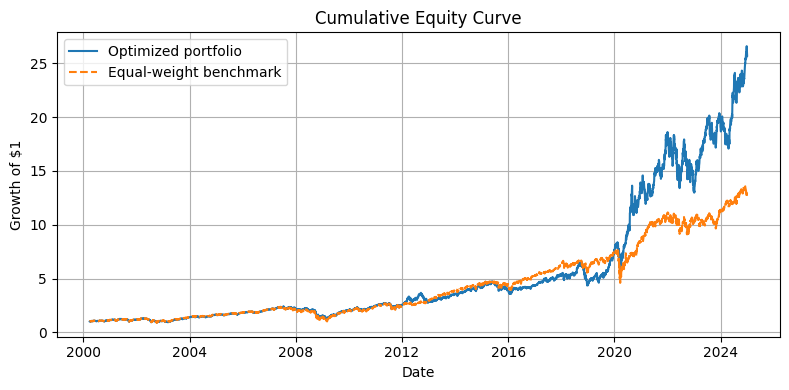

ROLLING_WINDOW = 24
GAMMA = 1.0
KAPPA = 0.0001
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (6289, 978)
universe hash sample = 6289 [(Timestamp('2000-01-03 00:00:00'), []), (Timestamp('2000-01-04 00:00:00'), [])]
estimate_moments id = 140052508747040
optimize_weights id = 140052507128704


In [ ]:
# ============================================================
# SAME SETUP AS YOUR MONTHLY MODEL, NOW RUN ON THE UPLOADED DAILY df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------
# 1. CLEAN THE UPLOADED DATA AND BUILD THE DAILY PANEL
# -------------------------------------------------
# Assumes your upload cell already created: df

# Parse dates and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'permno']).copy()

# Standard CRSP-style filters
if 'shrcd' in df.columns:
    df = df[df['shrcd'].isin([10, 11])].copy()

if 'exchcd' in df.columns:
    df = df[df['exchcd'].isin([1, 2, 3])].copy()

# Clean returns
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.dropna(subset=['ret']).copy()

print("Unique dates in filtered data:", df['date'].nunique())
print("Unique permnos in filtered data:", df['permno'].nunique())

# Build raw return panel
ret_panel_full = (
    df.pivot_table(index='date', columns='permno', values='ret', aggfunc='first')
      .sort_index()
)

print("Raw panel shape (T x N):", ret_panel_full.shape)

# -----------------------------
# Dynamic universe parameters
# -----------------------------
MIN_HISTORY = 60       # same setup as monthly notebook
K_UNIVERSE = 350
MIN_PRICE = 0.1

# Optional price panel for screening
if 'prc' in df.columns:
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce')
    prc_panel_full = (
        df.pivot_table(index='date', columns='permno', values='prc', aggfunc='first')
          .sort_index()
          .abs()
    )
else:
    prc_panel_full = None

# Rolling count of available past returns, shifted so only information up to t is used
hist_count = ret_panel_full.notna().rolling(MIN_HISTORY).sum().shift(1)

# Build date-specific eligible universes
eligible_universe_by_date = {}

for date in ret_panel_full.index:
    eligible = hist_count.loc[date]
    eligible = eligible[eligible >= MIN_HISTORY].index.tolist()

    # Optional price filter using only info at date t
    if prc_panel_full is not None and date in prc_panel_full.index:
        eligible = [
            p for p in eligible
            if pd.notna(prc_panel_full.loc[date, p]) and prc_panel_full.loc[date, p] >= MIN_PRICE
        ]

    # Keep only up to K_UNIVERSE names
    eligible = eligible[:K_UNIVERSE]

    eligible_universe_by_date[date] = eligible

# Quick summary of universe sizes over time
universe_sizes = pd.Series({d: len(v) for d, v in eligible_universe_by_date.items()})
print("Universe size summary:")
print(universe_sizes.describe())

print("\nFirst few nonempty universes:")
for d in universe_sizes[universe_sizes > 0].index[:5]:
    print(d.date(), "->", len(eligible_universe_by_date[d]), "stocks")

# -------------------------------------------------
# 2. SAME HELPER SETUP AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Store previous weights by permno, since the universe changes over time
w_prev_dict = None

# Hyperparameters
ROLLING_WINDOW = 24   # same as monthly notebook
GAMMA = 1.0
KAPPA = 0.0001
LR = 0.1
STEPS = 1000

dates = ret_panel_full.index.to_list()

print(f"#dates in full panel: {len(dates)}")
print("Universe size summary:")
print(universe_sizes.describe())


def estimate_moments(window_returns: pd.DataFrame):
    """
    window_returns: (T_window x N) DataFrame of past returns
    Returns:
        mu_t : (N,) mean vector
        Sigma_t : (N, N) covariance matrix
    """
    mu_t = window_returns.mean(axis=0).values
    Sigma_t = window_returns.cov().values

    # Ensure symmetry and add small jitter for stability
    Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
    eps = 1e-6
    Sigma_t = Sigma_t + eps * np.eye(Sigma_t.shape[0])

    return mu_t, Sigma_t


def get_prev_weights_for_current_universe(current_permnos, w_prev_dict):
    """
    Align previous weights to the current universe.
    Any stock not held previously gets weight 0.
    If no previous portfolio exists, start from equal weights.
    """
    current_N = len(current_permnos)

    if w_prev_dict is None:
        return np.ones(current_N) / current_N

    w_prev = np.array([w_prev_dict.get(p, 0.0) for p in current_permnos], dtype=float)

    # Renormalize if any mass remains; otherwise fall back to equal weights
    total = w_prev.sum()
    if total > 0:
        w_prev = w_prev / total
    else:
        w_prev = np.ones(current_N) / current_N

    return w_prev


def optimize_weights(mu_t, Sigma_t, w_prev=None):
    """
    Solve:
      max_w mu_t^T w - GAMMA * w^T Sigma_t w - KAPPA * ||w - w_prev||_1
      s.t. w lies on the simplex
    using logits + softmax in PyTorch.
    """
    mu_t_t = torch.tensor(mu_t, dtype=torch.float32, device=DEVICE)
    Sigma_t_t = torch.tensor(Sigma_t, dtype=torch.float32, device=DEVICE)

    current_N = mu_t.shape[0]

    if w_prev is None:
        w_prev_np = np.ones(current_N) / current_N
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)

    w_prev_t = torch.tensor(w_prev_np, dtype=torch.float32, device=DEVICE)

    # Initialize logits near previous weights
    v = torch.log(w_prev_t + 1e-8)
    v = v.detach().clone().requires_grad_(True)

    optimizer = torch.optim.SGD([v], lr=LR)

    for _ in range(STEPS):
        optimizer.zero_grad()

        w = torch.softmax(v, dim=0)
        exp_ret = torch.dot(mu_t_t, w)
        var = w @ Sigma_t_t @ w
        turnover = torch.abs(w - w_prev_t).sum()

        objective = exp_ret - GAMMA * var - KAPPA * turnover
        loss = -objective
        loss.backward()
        optimizer.step()

    w_opt = torch.softmax(v, dim=0).detach().cpu().numpy()
    return w_opt

# -------------------------------------------------
# 3. SAME BACKTEST LOOP AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
portfolio_returns = []
benchmark_returns = []
weight_history = []

# Previous portfolio stored by permno
w_prev_dict = None

# Rebalance through time
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t, based only on info available at t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if the eligible universe is too small
    if len(current_permnos) < 2:
        continue

    # Use the previous ROLLING_WINDOW periods for estimation
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Require a fully observed estimation window for the current universe
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    # Need at least 2 assets left after missing-data filtering
    if len(current_permnos) < 2:
        continue

    # Get next-period realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]

    # Same safe rule as monthly notebook
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments from the rolling window
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to the current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize at time t
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno for turnover alignment next period
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history.append((date_t, current_permnos, w_t))

    port_ret = float(np.dot(w_t, r_next_eval.values))

    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    portfolio_returns.append(port_ret)
    benchmark_returns.append(bench_ret)

print(len(portfolio_returns), len(benchmark_returns))

# -------------------------------------------------
# 4. SAME PERFORMANCE BLOCK AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
def performance_metrics(returns, freq=12):
    returns = np.asarray(returns, dtype=float)

    if len(returns) == 0:
        return {
            "mean_ret_monthly": np.nan,
            "vol_annual": np.nan,
            "sharpe_annual": np.nan,
            "max_drawdown": np.nan,
            "cum_return": np.nan,
            "equity_curve": np.array([]),
        }

    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1) if len(returns) > 1 else np.nan

    if std_ret is not np.nan and std_ret > 0:
        sharpe = np.sqrt(freq) * mean_ret / std_ret
    else:
        sharpe = np.nan

    vol_annual = std_ret * np.sqrt(freq) if not np.isnan(std_ret) else np.nan

    equity = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_cum_ret = equity[-1] - 1.0

    return {
        "mean_ret_monthly": mean_ret,
        "vol_annual": vol_annual,
        "sharpe_annual": sharpe,
        "max_drawdown": max_dd,
        "cum_return": total_cum_ret,
        "equity_curve": equity,
    }

port_ret_arr = np.array(portfolio_returns, dtype=float)
bench_ret_arr = np.array(benchmark_returns, dtype=float)

metrics_port = performance_metrics(port_ret_arr, freq=12)
metrics_bench = performance_metrics(bench_ret_arr, freq=12)

print("Optimized portfolio:")
for k, v in metrics_port.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\nEqual-weight benchmark:")
for k, v in metrics_bench.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual rebalance dates if available
backtest_dates = [x[0] for x in weight_history]

plt.figure(figsize=(8, 4))
plt.plot(backtest_dates, metrics_port["equity_curve"], label="Optimized portfolio")
plt.plot(backtest_dates, metrics_bench["equity_curve"], label="Equal-weight benchmark", linestyle="--")
plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

Unique dates in filtered data: 6289
Unique permnos in filtered data: 978
Raw panel shape (T x N): (6289, 978)
Using properly rescaled daily settings:
ROLLING_WINDOW = 504
MIN_HISTORY = 1260
GAMMA = 1.0
KAPPA = 4.761904761904762e-06
LR = 0.1
STEPS = 1000
Universe size summary:
count    6289.000000
mean      279.359358
std       139.853082
min         0.000000
25%       345.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64

First few nonempty universes:
2005-01-07 -> 350 stocks
2005-01-10 -> 350 stocks
2005-01-11 -> 350 stocks
2005-01-12 -> 350 stocks
2005-01-13 -> 350 stocks
#dates in full panel: 6289
Universe size summary:
count    6289.000000
mean      279.359358
std       139.853082
min         0.000000
25%       345.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64
5028 5028
Optimized portfolio:
  mean_ret_daily: 0.000713
  vol_annual: 0.253244
  sharpe_annual: 0.709854
  max_drawdown: -0.565818
  cum_return: 18.0

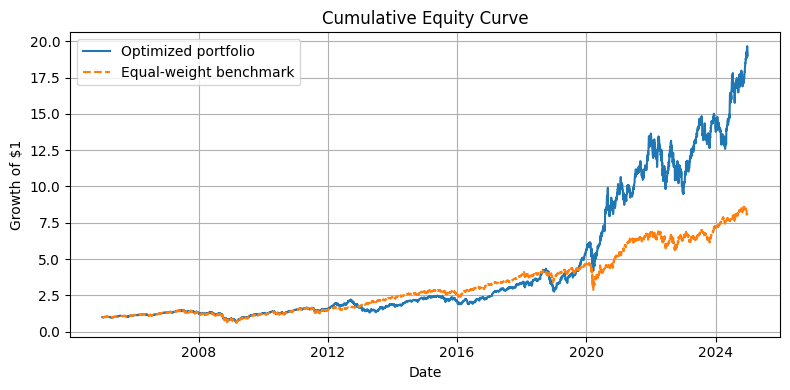

ROLLING_WINDOW = 504
MIN_HISTORY = 1260
GAMMA = 1.0
KAPPA = 4.761904761904762e-06
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (6289, 978)
universe hash sample = 6289 [(Timestamp('2000-01-03 00:00:00'), []), (Timestamp('2000-01-04 00:00:00'), [])]
estimate_moments id = 140052433403744
optimize_weights id = 140052508746400


In [ ]:
# ============================================================
# PROPERLY RESCALED DAILY VERSION OF YOUR MONTHLY MODEL
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------
# 1. CLEAN THE UPLOADED DATA AND BUILD THE DAILY PANEL
# -------------------------------------------------
# Assumes your upload cell already created: df

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'permno']).copy()

# Standard CRSP-style filters
if 'shrcd' in df.columns:
    df = df[df['shrcd'].isin([10, 11])].copy()

if 'exchcd' in df.columns:
    df = df[df['exchcd'].isin([1, 2, 3])].copy()

# Clean returns
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.dropna(subset=['ret']).copy()

print("Unique dates in filtered data:", df['date'].nunique())
print("Unique permnos in filtered data:", df['permno'].nunique())

# Build raw return panel
ret_panel_full = (
    df.pivot_table(index='date', columns='permno', values='ret', aggfunc='first')
      .sort_index()
)

print("Raw panel shape (T x N):", ret_panel_full.shape)

# -----------------------------
# Daily rescaling constants
# -----------------------------
TRADING_DAYS_PER_MONTH = 21
TRADING_DAYS_PER_YEAR = 252

# -----------------------------
# Monthly model settings
# -----------------------------
ROLLING_WINDOW_MONTHS = 24
MIN_HISTORY_MONTHS = 60

# Use your tuned monthly hyperparameters here
GAMMA_MONTHLY = 1.0
KAPPA_MONTHLY = 0.0001
LR = 0.1
STEPS = 1000

# -----------------------------
# Proper daily rescaling
# -----------------------------
ROLLING_WINDOW = ROLLING_WINDOW_MONTHS * TRADING_DAYS_PER_MONTH
MIN_HISTORY = MIN_HISTORY_MONTHS * TRADING_DAYS_PER_MONTH

# Keep gamma the same, scale turnover penalty to daily
GAMMA = GAMMA_MONTHLY
KAPPA = KAPPA_MONTHLY / TRADING_DAYS_PER_MONTH

K_UNIVERSE = 350
MIN_PRICE = 0.1

print("Using properly rescaled daily settings:")
print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("MIN_HISTORY =", MIN_HISTORY)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)

# Optional price panel for screening
if 'prc' in df.columns:
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce')
    prc_panel_full = (
        df.pivot_table(index='date', columns='permno', values='prc', aggfunc='first')
          .sort_index()
          .abs()
    )
else:
    prc_panel_full = None

# Rolling count of available past returns, shifted so only information up to t is used
hist_count = ret_panel_full.notna().rolling(MIN_HISTORY).sum().shift(1)

# Build date-specific eligible universes
eligible_universe_by_date = {}

for date in ret_panel_full.index:
    eligible = hist_count.loc[date]
    eligible = eligible[eligible >= MIN_HISTORY].index.tolist()

    # Optional price filter using only info at date t
    if prc_panel_full is not None and date in prc_panel_full.index:
        eligible = [
            p for p in eligible
            if pd.notna(prc_panel_full.loc[date, p]) and prc_panel_full.loc[date, p] >= MIN_PRICE
        ]

    eligible = eligible[:K_UNIVERSE]
    eligible_universe_by_date[date] = eligible

universe_sizes = pd.Series({d: len(v) for d, v in eligible_universe_by_date.items()})
print("Universe size summary:")
print(universe_sizes.describe())

print("\nFirst few nonempty universes:")
for d in universe_sizes[universe_sizes > 0].index[:5]:
    print(d.date(), "->", len(eligible_universe_by_date[d]), "stocks")

# -------------------------------------------------
# 2. HELPER SETUP
# -------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

w_prev_dict = None
dates = ret_panel_full.index.to_list()

print(f"#dates in full panel: {len(dates)}")
print("Universe size summary:")
print(universe_sizes.describe())


def estimate_moments(window_returns: pd.DataFrame):
    """
    window_returns: (T_window x N) DataFrame of past returns
    Returns:
        mu_t : (N,) mean vector
        Sigma_t : (N, N) covariance matrix
    """
    mu_t = window_returns.mean(axis=0).values
    Sigma_t = window_returns.cov().values

    Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
    eps = 1e-6
    Sigma_t = Sigma_t + eps * np.eye(Sigma_t.shape[0])

    return mu_t, Sigma_t


def get_prev_weights_for_current_universe(current_permnos, w_prev_dict):
    """
    Align previous weights to the current universe.
    Any stock not held previously gets weight 0.
    If no previous portfolio exists, start from equal weights.
    """
    current_N = len(current_permnos)

    if w_prev_dict is None:
        return np.ones(current_N) / current_N

    w_prev = np.array([w_prev_dict.get(p, 0.0) for p in current_permnos], dtype=float)

    total = w_prev.sum()
    if total > 0:
        w_prev = w_prev / total
    else:
        w_prev = np.ones(current_N) / current_N

    return w_prev


def optimize_weights(mu_t, Sigma_t, w_prev=None):
    """
    Solve:
      max_w mu_t^T w - GAMMA * w^T Sigma_t w - KAPPA * ||w - w_prev||_1
      s.t. w lies on the simplex
    using logits + softmax in PyTorch.
    """
    mu_t_t = torch.tensor(mu_t, dtype=torch.float32, device=DEVICE)
    Sigma_t_t = torch.tensor(Sigma_t, dtype=torch.float32, device=DEVICE)

    current_N = mu_t.shape[0]

    if w_prev is None:
        w_prev_np = np.ones(current_N) / current_N
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)

    w_prev_t = torch.tensor(w_prev_np, dtype=torch.float32, device=DEVICE)

    v = torch.log(w_prev_t + 1e-8)
    v = v.detach().clone().requires_grad_(True)

    optimizer = torch.optim.SGD([v], lr=LR)

    for _ in range(STEPS):
        optimizer.zero_grad()

        w = torch.softmax(v, dim=0)
        exp_ret = torch.dot(mu_t_t, w)
        var = w @ Sigma_t_t @ w
        turnover = torch.abs(w - w_prev_t).sum()

        objective = exp_ret - GAMMA * var - KAPPA * turnover
        loss = -objective
        loss.backward()
        optimizer.step()

    w_opt = torch.softmax(v, dim=0).detach().cpu().numpy()
    return w_opt


# -------------------------------------------------
# 3. BACKTEST LOOP
# -------------------------------------------------
portfolio_returns = []
benchmark_returns = []
weight_history = []

w_prev_dict = None

for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    current_permnos = eligible_universe_by_date.get(date_t, [])

    if len(current_permnos) < 2:
        continue

    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    mu_t, Sigma_t = estimate_moments(window_ret)
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}
    weight_history.append((date_t, current_permnos, w_t))

    port_ret = float(np.dot(w_t, r_next_eval.values))

    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    portfolio_returns.append(port_ret)
    benchmark_returns.append(bench_ret)

print(len(portfolio_returns), len(benchmark_returns))

# -------------------------------------------------
# 4. DAILY PERFORMANCE METRICS
# -------------------------------------------------
def performance_metrics(returns, freq=TRADING_DAYS_PER_YEAR):
    returns = np.asarray(returns, dtype=float)

    if len(returns) == 0:
        return {
            "mean_ret_daily": np.nan,
            "vol_annual": np.nan,
            "sharpe_annual": np.nan,
            "max_drawdown": np.nan,
            "cum_return": np.nan,
            "equity_curve": np.array([]),
        }

    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1) if len(returns) > 1 else np.nan

    if not np.isnan(std_ret) and std_ret > 0:
        sharpe = np.sqrt(freq) * mean_ret / std_ret
    else:
        sharpe = np.nan

    vol_annual = std_ret * np.sqrt(freq) if not np.isnan(std_ret) else np.nan

    equity = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_cum_ret = equity[-1] - 1.0

    return {
        "mean_ret_daily": mean_ret,
        "vol_annual": vol_annual,
        "sharpe_annual": sharpe,
        "max_drawdown": max_dd,
        "cum_return": total_cum_ret,
        "equity_curve": equity,
    }

port_ret_arr = np.array(portfolio_returns, dtype=float)
bench_ret_arr = np.array(benchmark_returns, dtype=float)

metrics_port = performance_metrics(port_ret_arr, freq=TRADING_DAYS_PER_YEAR)
metrics_bench = performance_metrics(bench_ret_arr, freq=TRADING_DAYS_PER_YEAR)

print("Optimized portfolio:")
for k, v in metrics_port.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.6f}" if not np.isnan(v) else f"  {k}: nan")

print("\nEqual-weight benchmark:")
for k, v in metrics_bench.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.6f}" if not np.isnan(v) else f"  {k}: nan")

backtest_dates = [x[0] for x in weight_history]

plt.figure(figsize=(8, 4))
plt.plot(backtest_dates, metrics_port["equity_curve"], label="Optimized portfolio")
plt.plot(backtest_dates, metrics_bench["equity_curve"], label="Equal-weight benchmark", linestyle="--")
plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("MIN_HISTORY =", MIN_HISTORY)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

Unique dates in filtered data: 6289
Unique permnos in filtered data: 978
Raw panel shape (T x N): (6289, 978)
Universe size summary:
count    6289.000000
mean      346.660836
std        34.025598
min         0.000000
25%       350.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64

First few nonempty universes:
2000-03-29 -> 350 stocks
2000-03-30 -> 350 stocks
2000-03-31 -> 350 stocks
2000-04-03 -> 350 stocks
2000-04-04 -> 350 stocks
#dates in full panel: 6289
Universe size summary:
count    6289.000000
mean      346.660836
std        34.025598
min         0.000000
25%       350.000000
50%       350.000000
75%       350.000000
max       350.000000
dtype: float64
6228 6228
Optimized portfolio:
  mean_ret_monthly: 0.0007
  vol_annual: 0.0509
  sharpe_annual: 0.1533
  max_drawdown: -0.5315
  cum_return: 28.3061

Equal-weight benchmark:
  mean_ret_monthly: 0.0005
  vol_annual: 0.0440
  sharpe_annual: 0.1337
  max_drawdown: -0.5703
  cum_return: 11.7823


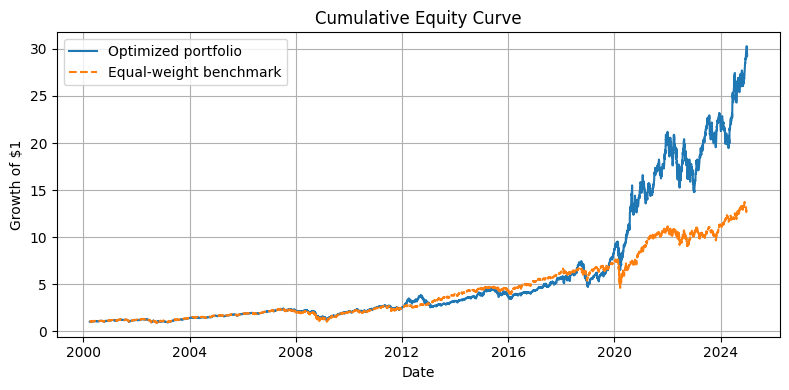

ROLLING_WINDOW = 60
GAMMA = 1.0
KAPPA = 0.0001
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (6289, 978)
universe hash sample = 6289 [(Timestamp('2000-01-03 00:00:00'), []), (Timestamp('2000-01-04 00:00:00'), [])]
estimate_moments id = 140052507124544
optimize_weights id = 140052508748480


In [ ]:
# ============================================================
# SAME SETUP AS YOUR MONTHLY MODEL, NOW RUN ON THE UPLOADED DAILY df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# -------------------------------------------------
# 1. CLEAN THE UPLOADED DATA AND BUILD THE DAILY PANEL
# -------------------------------------------------
# Assumes your upload cell already created: df

# Parse dates and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'permno']).copy()

# Standard CRSP-style filters
if 'shrcd' in df.columns:
    df = df[df['shrcd'].isin([10, 11])].copy()

if 'exchcd' in df.columns:
    df = df[df['exchcd'].isin([1, 2, 3])].copy()

# Clean returns
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.dropna(subset=['ret']).copy()

print("Unique dates in filtered data:", df['date'].nunique())
print("Unique permnos in filtered data:", df['permno'].nunique())

# Build raw return panel
ret_panel_full = (
    df.pivot_table(index='date', columns='permno', values='ret', aggfunc='first')
      .sort_index()
)

print("Raw panel shape (T x N):", ret_panel_full.shape)

# -----------------------------
# Dynamic universe parameters
# -----------------------------
MIN_HISTORY = 60       # same setup as monthly notebook
K_UNIVERSE = 350
MIN_PRICE = 0.1

# Optional price panel for screening
if 'prc' in df.columns:
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce')
    prc_panel_full = (
        df.pivot_table(index='date', columns='permno', values='prc', aggfunc='first')
          .sort_index()
          .abs()
    )
else:
    prc_panel_full = None

# Rolling count of available past returns, shifted so only information up to t is used
hist_count = ret_panel_full.notna().rolling(MIN_HISTORY).sum().shift(1)

# Build date-specific eligible universes
eligible_universe_by_date = {}

for date in ret_panel_full.index:
    eligible = hist_count.loc[date]
    eligible = eligible[eligible >= MIN_HISTORY].index.tolist()

    # Optional price filter using only info at date t
    if prc_panel_full is not None and date in prc_panel_full.index:
        eligible = [
            p for p in eligible
            if pd.notna(prc_panel_full.loc[date, p]) and prc_panel_full.loc[date, p] >= MIN_PRICE
        ]

    # Keep only up to K_UNIVERSE names
    eligible = eligible[:K_UNIVERSE]

    eligible_universe_by_date[date] = eligible

# Quick summary of universe sizes over time
universe_sizes = pd.Series({d: len(v) for d, v in eligible_universe_by_date.items()})
print("Universe size summary:")
print(universe_sizes.describe())

print("\nFirst few nonempty universes:")
for d in universe_sizes[universe_sizes > 0].index[:5]:
    print(d.date(), "->", len(eligible_universe_by_date[d]), "stocks")

# -------------------------------------------------
# 2. SAME HELPER SETUP AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Store previous weights by permno, since the universe changes over time
w_prev_dict = None

# Hyperparameters
ROLLING_WINDOW = 60   # same as monthly notebook
GAMMA = 1.0
KAPPA = 0.0001
LR = 0.1
STEPS = 1000

dates = ret_panel_full.index.to_list()

print(f"#dates in full panel: {len(dates)}")
print("Universe size summary:")
print(universe_sizes.describe())


def estimate_moments(window_returns: pd.DataFrame):
    """
    window_returns: (T_window x N) DataFrame of past returns
    Returns:
        mu_t : (N,) mean vector
        Sigma_t : (N, N) covariance matrix
    """
    mu_t = window_returns.mean(axis=0).values
    Sigma_t = window_returns.cov().values

    # Ensure symmetry and add small jitter for stability
    Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
    eps = 1e-6
    Sigma_t = Sigma_t + eps * np.eye(Sigma_t.shape[0])

    return mu_t, Sigma_t


def get_prev_weights_for_current_universe(current_permnos, w_prev_dict):
    """
    Align previous weights to the current universe.
    Any stock not held previously gets weight 0.
    If no previous portfolio exists, start from equal weights.
    """
    current_N = len(current_permnos)

    if w_prev_dict is None:
        return np.ones(current_N) / current_N

    w_prev = np.array([w_prev_dict.get(p, 0.0) for p in current_permnos], dtype=float)

    # Renormalize if any mass remains; otherwise fall back to equal weights
    total = w_prev.sum()
    if total > 0:
        w_prev = w_prev / total
    else:
        w_prev = np.ones(current_N) / current_N

    return w_prev


def optimize_weights(mu_t, Sigma_t, w_prev=None):
    """
    Solve:
      max_w mu_t^T w - GAMMA * w^T Sigma_t w - KAPPA * ||w - w_prev||_1
      s.t. w lies on the simplex
    using logits + softmax in PyTorch.
    """
    mu_t_t = torch.tensor(mu_t, dtype=torch.float32, device=DEVICE)
    Sigma_t_t = torch.tensor(Sigma_t, dtype=torch.float32, device=DEVICE)

    current_N = mu_t.shape[0]

    if w_prev is None:
        w_prev_np = np.ones(current_N) / current_N
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)

    w_prev_t = torch.tensor(w_prev_np, dtype=torch.float32, device=DEVICE)

    # Initialize logits near previous weights
    v = torch.log(w_prev_t + 1e-8)
    v = v.detach().clone().requires_grad_(True)

    optimizer = torch.optim.SGD([v], lr=LR)

    for _ in range(STEPS):
        optimizer.zero_grad()

        w = torch.softmax(v, dim=0)
        exp_ret = torch.dot(mu_t_t, w)
        var = w @ Sigma_t_t @ w
        turnover = torch.abs(w - w_prev_t).sum()

        objective = exp_ret - GAMMA * var - KAPPA * turnover
        loss = -objective
        loss.backward()
        optimizer.step()

    w_opt = torch.softmax(v, dim=0).detach().cpu().numpy()
    return w_opt

# -------------------------------------------------
# 3. SAME BACKTEST LOOP AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
portfolio_returns = []
benchmark_returns = []
weight_history = []

# Previous portfolio stored by permno
w_prev_dict = None

# Rebalance through time
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t, based only on info available at t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if the eligible universe is too small
    if len(current_permnos) < 2:
        continue

    # Use the previous ROLLING_WINDOW periods for estimation
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Require a fully observed estimation window for the current universe
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    # Need at least 2 assets left after missing-data filtering
    if len(current_permnos) < 2:
        continue

    # Get next-period realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]

    # Same safe rule as monthly notebook
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments from the rolling window
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to the current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize at time t
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno for turnover alignment next period
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history.append((date_t, current_permnos, w_t))

    port_ret = float(np.dot(w_t, r_next_eval.values))

    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    portfolio_returns.append(port_ret)
    benchmark_returns.append(bench_ret)

print(len(portfolio_returns), len(benchmark_returns))

# -------------------------------------------------
# 4. SAME PERFORMANCE BLOCK AS YOUR MONTHLY NOTEBOOK
# -------------------------------------------------
def performance_metrics(returns, freq=12):
    returns = np.asarray(returns, dtype=float)

    if len(returns) == 0:
        return {
            "mean_ret_monthly": np.nan,
            "vol_annual": np.nan,
            "sharpe_annual": np.nan,
            "max_drawdown": np.nan,
            "cum_return": np.nan,
            "equity_curve": np.array([]),
        }

    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1) if len(returns) > 1 else np.nan

    if std_ret is not np.nan and std_ret > 0:
        sharpe = np.sqrt(freq) * mean_ret / std_ret
    else:
        sharpe = np.nan

    vol_annual = std_ret * np.sqrt(freq) if not np.isnan(std_ret) else np.nan

    equity = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_cum_ret = equity[-1] - 1.0

    return {
        "mean_ret_monthly": mean_ret,
        "vol_annual": vol_annual,
        "sharpe_annual": sharpe,
        "max_drawdown": max_dd,
        "cum_return": total_cum_ret,
        "equity_curve": equity,
    }

port_ret_arr = np.array(portfolio_returns, dtype=float)
bench_ret_arr = np.array(benchmark_returns, dtype=float)

metrics_port = performance_metrics(port_ret_arr, freq=12)
metrics_bench = performance_metrics(bench_ret_arr, freq=12)

print("Optimized portfolio:")
for k, v in metrics_port.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\nEqual-weight benchmark:")
for k, v in metrics_bench.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual rebalance dates if available
backtest_dates = [x[0] for x in weight_history]

plt.figure(figsize=(8, 4))
plt.plot(backtest_dates, metrics_port["equity_curve"], label="Optimized portfolio")
plt.plot(backtest_dates, metrics_bench["equity_curve"], label="Equal-weight benchmark", linestyle="--")
plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))